# EDA – Porto taxi

| Del | Innhold |
|---|---|
| 1 | Oppsett |
| 2 | Oversikt over datasettet |
| 3 | Datakvalitet: NaN, MISSING_DATA, TRIP_ID-duplikater |
| 4 | Rensing (samme regler som `insert_data.py`) |
| 5 | Datatransformasjon: typekonvertering, POLYLINE og avledede kolonner |
| 6 | Fordeling av hovedattributter |
| 7 | Ugyldige turer og outliers, med beslutningstabell |

# 1. Oppsett

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from haversine import haversine

FIG_DIR = Path("figures")       # lagre plott her, så de kan brukes i rapporten
FIG_DIR.mkdir(exist_ok=True)

# Hele filen er ~1,9 GB. Sett f.eks. 100_000 for å teste raskt, None for alt.
NROWS = None

# Et steg på mer enn 1 km mellom to punkter (15 s) er over 240 km/t,
# og regnes som et GPS-hopp. Samme terskel som i insert_data.py.
MAX_STEP_KM = 1.0

In [2]:
# Felles stil for figurene i rapporten. Figurene lagres i figures/eda/.
from matplotlib.ticker import FuncFormatter

FARGE = "#2b7bd6"
plt.rcParams.update({
    "figure.figsize": (6.4, 3.4),
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#aaaaaa",
    "axes.labelcolor": "#555555",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#e3e3e3",
    "axes.axisbelow": True,
})


def tall(x, des=0):
    """Norsk tallformat: 1 710 579 og 47,8."""
    return f"{x:,.{des}f}".replace(",", " ").replace(".", ",")


def tusenskille(ax, akser="y"):
    formatter = FuncFormatter(lambda v, _: tall(v))
    if "x" in akser:
        ax.xaxis.set_major_formatter(formatter)
    if "y" in akser:
        ax.yaxis.set_major_formatter(formatter)


def lagre(fig, navn):
    mappe = FIG_DIR / "eda"
    mappe.mkdir(exist_ok=True)
    fig.tight_layout()
    fig.savefig(mappe / navn, dpi=200, bbox_inches="tight")
    plt.show()

---
# 2. Oversikt over datasettet

In [3]:
df = pd.read_csv("data/porto.csv", nrows=NROWS)

df.head()

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [4]:
print(df.head())
print("(Antall rader, antall kolonner)",df.shape)

               TRIP_ID CALL_TYPE  ORIGIN_CALL  ORIGIN_STAND   TAXI_ID  \
0  1372636858620000589         C          NaN           NaN  20000589   
1  1372637303620000596         B          NaN           7.0  20000596   
2  1372636951620000320         C          NaN           NaN  20000320   
3  1372636854620000520         C          NaN           NaN  20000520   
4  1372637091620000337         C          NaN           NaN  20000337   

    TIMESTAMP DAY_TYPE  MISSING_DATA  \
0  1372636858        A         False   
1  1372637303        A         False   
2  1372636951        A         False   
3  1372636854        A         False   
4  1372637091        A         False   

                                            POLYLINE  
0  [[-8.618643,41.141412],[-8.618499,41.141376],[...  
1  [[-8.639847,41.159826],[-8.640351,41.159871],[...  
2  [[-8.612964,41.140359],[-8.613378,41.14035],[-...  
3  [[-8.574678,41.151951],[-8.574705,41.151942],[...  
4  [[-8.645994,41.18049],[-8.645949,41.180517

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1710670 entries, 0 to 1710669
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   TRIP_ID       int64  
 1   CALL_TYPE     str    
 2   ORIGIN_CALL   float64
 3   ORIGIN_STAND  float64
 4   TAXI_ID       int64  
 5   TIMESTAMP     int64  
 6   DAY_TYPE      str    
 7   MISSING_DATA  bool   
 8   POLYLINE      str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 106.0 MB


---
# 3. Datakvalitet

## 3.1 Manglende verdier (NaN)

In [6]:
display(df.isna().sum())

TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

In [7]:
pd.crosstab(
    df["CALL_TYPE"],
    df["ORIGIN_CALL"].isna(),
    rownames=["CALL_TYPE"],
    colnames=["ORIGIN_CALL missing"]
)


ORIGIN_CALL missing,False,True
CALL_TYPE,,
A,364770,0
B,0,817881
C,0,528019


In [8]:
pd.crosstab(
    df["CALL_TYPE"],
    df["ORIGIN_STAND"].isna(),
    rownames=["CALL_TYPE"],
    colnames=["ORIGIN_STAND missing"]
)

ORIGIN_STAND missing,False,True
CALL_TYPE,,
A,0,364770
B,806579,11302
C,0,528019


In [9]:
df["CALL_TYPE"].value_counts()

CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64

Gjennom analysen av NaN verdier hittil ser vi at det er en god del NaN verdier som mangler i ORIGIN_CALL og ORIGIN_STAND. Her kan man fort tenke at det er smart å kvitte seg med disse verdiene eller gjøre noe form for dataimputering, men før en beslutning må vi forstå hva kolonnene og potensielle Null verdier representerer.

Ifølge oppgaven er ORIGIN_CALL IDen til kunden som initierte samtalen, og har kun en verdi når CALL_TYPE = A, ellers null. ORIGIN_STAND er IDen til taxistanden hvor turen startet, og har en verdi kun hvis CALL_TYPE = B. Dette forteller oss at vi må se på relasjonen mellom CALL_TYPE og ORIGIN_STAND/CALL:

Vi lagde derfor to crosstabs som forteller oss hvor og når NaN verdier oppstår. Ifølge crosstaben ser vi at når CALL_TYPE = A så finnes det ingen NaN verdier i ORIGIN_CALL, men når den er B eller C er alle NaN. Dette henger med beskrivelsen av selve kolonnen. For ORIGIN_STAND er det fortsatt 11302 NaN verdier når CALL_TYPE = B. Disse verdiene er faktiske mangler i datasettet. Vi velger å beholde alle NaN verdier, også de som viser til faktiske mangler. Dette er fordi ORIGIN_STAND ikke er veldig sentralt i senere analyser, og ved å slette 11000 rader kan vi miste annen verdifull informasjon. Imputering er heller ikke relevant med tanke på at det ikke finnes en pålitelig måte å legge til ID-verdier.

## 3.2 MISSING_DATA

In [10]:
print("Rows with missing GPS points:", df["MISSING_DATA"].sum())

Rows with missing GPS points: 10


MISSING_DATA forteller oss om det finnes turer som mangler GPS punkter, og vi ser at det finnes 10 turer med gps mangler. I senere analyser er POLYLINE sentralt fordi vi skal blant annet finne ut varighet, tid, distanse og lignende. Hvis vi mangler GPS-punkter, vet vi ikke om de manglende punktene ligger i starten, midten eller slutten av turen. Dermed kan vi heller ikke være sikre på at det faktisk er 15 sekunder mellom alle registrerte punkter i disse 10 radene. Imputering av gps punkter her vil heller ikke gå fordi vi ikke vet hvor manglene ligger. Vi velger derfor å slette disse 10 radene grunnet at dette vil øke påliteligheten til POLYLINE kolonnen, og det er så få rader at vi ikke mister masse verdifull data.

In [11]:
# Ser turene med MISSING_DATA = True annerledes ut enn resten?
print(df["MISSING_DATA"].value_counts())
n_points = (df["POLYLINE"].str.count(r"\[") - 1).clip(lower=0)
n_points.groupby(df["MISSING_DATA"]).describe()

MISSING_DATA
False    1710660
True          10
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
MISSING_DATA,,,,,,,,
False,1710660.0,48.758033,45.652243,0.0,28.00,41.0,59.0,3881.0
True,10.0,96.900000,159.486990,1.0,11.75,35.0,52.5,483.0


**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

Oppgaven nevner dette eksplisitt («investigate the presence and impact of missing trajectories»).
- Ser disse turene annerledes ut enn resten?
- Konsekvens: beholde, flagge eller fjerne? Hva betyr valget for varighet/distanse i Part 2?

## 3.3 TRIP_ID-duplikater

In [12]:
print("Overskytende rader med samme TRIP_ID:", df["TRIP_ID"].duplicated().sum())
print("Helt identiske rader:", df.duplicated().sum())

duplicates = df[df["TRIP_ID"].duplicated(keep=False)]
duplicates.sort_values("TRIP_ID").head(20)

Overskytende rader med samme TRIP_ID: 81


Helt identiske rader: 3


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
3519,1372702836620000080,B,NaN,16.0,20000080,1372702836,A,False,"[[-8.635275,41.193729],[-8.634519,41.192901]]"
3720,1372702836620000080,C,NaN,NaN,20000080,1372702836,A,False,"[[-8.62776,41.17554],[-8.62776,41.17554],[-8.6..."
21282,1373025987620000601,A,2002.0,NaN,20000601,1373025987,A,False,[]
21385,1373025987620000601,C,NaN,NaN,20000601,1373025987,A,False,"[[-8.604108,41.182569],[-8.604072,41.182605],[..."
33228,1373210896620000598,B,NaN,57.0,20000598,1373210896,A,False,"[[-8.610885,41.145525]]"
33350,1373210896620000598,C,NaN,NaN,20000598,1373210896,A,False,"[[-8.610813,41.14548],[-8.610732,41.145579],[-..."
51623,1373551710620000014,B,NaN,49.0,20000014,1373551710,A,False,"[[-8.587278,41.147325],[-8.587278,41.147325]]"
51966,1373551710620000014,C,NaN,NaN,20000014,1373551710,A,False,"[[-8.602938,41.179716],[-8.603937,41.179932],[..."
76527,1374014097620000337,C,NaN,NaN,20000337,1374014097,A,False,"[[-8.648451,41.164785]]"
76596,1374014097620000337,C,NaN,NaN,20000337,1374014097,A,False,"[[-8.648478,41.164758],[-8.648478,41.164758],[..."


Resultatet over viser at 81 rader har en TRIP_ID som allerede finnes i datasettet. De er fordelt på 80 TRIP_ID-er. Bare 3 av radene er helt identiske med en annen rad. TRIP_ID kan derfor ikke brukes som primærnøkkel uten videre.

In [13]:
# Hva er forskjellig mellom radene som deler TRIP_ID?
dup = duplicates.copy()
dup["n_points"] = dup["POLYLINE"].str.count(r"\[") - 1
grupper = dup.groupby("TRIP_ID")

forskjeller = pd.Series({
    kol: int((grupper[kol].nunique(dropna=False) > 1).sum())
    for kol in ["CALL_TYPE", "ORIGIN_CALL", "ORIGIN_STAND", "TAXI_ID", "TIMESTAMP", "POLYLINE"]
}, name="TRIP_ID-er der kolonnen er ulik")
print(f"{grupper.ngroups} TRIP_ID-er forekommer mer enn én gang")
display(forskjeller)

forste_kortere = int((grupper["n_points"].first() < grupper["n_points"].max()).sum())
print(f"Første kopi har færre punkter enn den lengste i {forste_kortere} av {grupper.ngroups} tilfeller")

80 TRIP_ID-er forekommer mer enn én gang


CALL_TYPE       23
ORIGIN_CALL      5
ORIGIN_STAND    18
TAXI_ID          0
TIMESTAMP        0
POLYLINE        77
Name: TRIP_ID-er der kolonnen er ulik, dtype: int64

Første kopi har færre punkter enn den lengste i 51 av 80 tilfeller


TRIP_ID skal identifisere en tur unikt, men det ble funnet 81 dupliserte forekomster. Kun 3 rader var helt identiske. Ved nærmere inspeksjon hadde flere rader med samme TRIP_ID ulike verdier, blant annet forskjellig CALL_TYPE, ORIGIN_STAND og POLYLINE. Derfor fjerner vi kun de helt identiske radene, mens resten blir beholdt for å unngå å fjerne potensielt ulik informasjon. Hver rad får en egen autogenerert id i databasen.

---
# 4. Rensing
Alle rensesteg samlet. Samme regler som i `insert_data.py`.

In [14]:
# Fjern bare helt identiske rader. Ulike rader med samme TRIP_ID beholdes
# og får hver sin unike id i databasen. Samme regel som i insert_data.py.
for_rensing = len(df)
df = df.drop_duplicates().copy()
print(f"Fjernet {for_rensing - len(df)} identiske rader, {len(df):,} turer igjen")

Fjernet 3 identiske rader, 1,710,667 turer igjen


In [15]:
# 1. Fjern turer der GPS-data mangler
df = df[df["MISSING_DATA"] == False].copy()

# 2. MISSING_DATA er nå alltid False og trengs ikke lenger
df = df.drop(columns=["MISSING_DATA"])

In [16]:
# Del 5-7 bruker den rensede df fra del 4 (uten duplikater og MISSING_DATA-turer).
df = df.reset_index(drop=True)
print(f"{len(df):,} turer")

1,710,657 turer


---
# 5. Datatransformasjon

## 5.1 Typekonvertering

In [17]:
df["utc_start_time"] = pd.to_datetime(df.TIMESTAMP, unit="s", utc=True)

#kategoriske kolonner -> "category", sammenlign minnebruk før/etter
minne_for = df.memory_usage(deep=True)
print(minne_for/1024**2)

df["DAY_TYPE"] = df.DAY_TYPE.astype("category")
df["CALL_TYPE"] = df.CALL_TYPE.astype("category")
df.dtypes
minne_etter = df.memory_usage(deep=True)
print (minne_etter/1024**2)

Index                0.000126
TRIP_ID             13.051277
CALL_TYPE           81.570482
ORIGIN_CALL         13.051277
ORIGIN_STAND        13.051277
TAXI_ID             13.051277
TIMESTAMP           13.051277
DAY_TYPE            81.570482
POLYLINE          1813.842278
utc_start_time      13.051277
dtype: float64


Index                0.000126
TRIP_ID             13.051277
CALL_TYPE            1.631553
ORIGIN_CALL         13.051277
ORIGIN_STAND        13.051277
TAXI_ID             13.051277
TIMESTAMP           13.051277
DAY_TYPE             1.631457
POLYLINE          1813.842278
utc_start_time      13.051277
dtype: float64


**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

## 5.2 Parse POLYLINE
Å lagre alle polylinjene som lister krever rundt 10 GB minne for hele datasettet. Vi parser derfor hver tur én gang og tar bare vare på det som trengs: antall punkter, start/slutt-koordinater, distanse og antall GPS-hopp.

In [18]:
def polyline_features(polyline_text):
    """Parser én polylinje og regner ut det vi trenger fra den."""
    p = json.loads(polyline_text)
    n = len(p)
    if n == 0:
        return n, np.nan, np.nan, np.nan, np.nan, 0.0, 0
    distance, jumps = 0.0, 0
    for (lon1, lat1), (lon2, lat2) in zip(p, p[1:]):
        step = haversine((lat1, lon1), (lat2, lon2))   # haversine vil ha (lat, lon)
        if step > MAX_STEP_KM:
            jumps += 1                                  # GPS-hopp: ikke med i distansen
        else:
            distance += step
    return n, p[0][0], p[0][1], p[-1][0], p[-1][1], distance, jumps

features = pd.DataFrame(
    [polyline_features(t) for t in df["POLYLINE"]],
    columns=["N_POINTS", "start_lon", "start_lat", "end_lon", "end_lat", "distance_km", "gps_jumps"],
    index=df.index,
)
df = df.drop(columns=["POLYLINE"]).join(features)
df.dtypes

TRIP_ID                        int64
CALL_TYPE                   category
ORIGIN_CALL                  float64
ORIGIN_STAND                 float64
TAXI_ID                        int64
TIMESTAMP                      int64
DAY_TYPE                    category
utc_start_time    datetime64[s, UTC]
N_POINTS                       int64
start_lon                    float64
start_lat                    float64
end_lon                      float64
end_lat                      float64
distance_km                  float64
gps_jumps                      int64
dtype: object

## 5.3 Avledede features

In [19]:
#n_points og duration_s (N_POINTS er regnet ut i 5.2)
df["DURATION_S"] = (df.N_POINTS-1)*15
df["DURATION_S"] = df["DURATION_S"].clip(lower=0)
df["DURATION_S"].describe()

count    1.710657e+06
mean     7.164235e+02
std      6.847289e+02
min      0.000000e+00
25%      4.050000e+02
50%      6.000000e+02
75%      8.700000e+02
max      5.820000e+04
Name: DURATION_S, dtype: float64

In [20]:
#start_time, end_time, hour, weekday, month, crosses_midnight
df["end_time"] = df["utc_start_time"] + pd.to_timedelta(df["DURATION_S"], unit="s")

df["hour"] = df["utc_start_time"].dt.hour

#0=monday
df["weekday"] = df["utc_start_time"].dt.weekday

df["month"] = df["utc_start_time"].dt.month

df["crosses_midnight"] = df["utc_start_time"].dt.date != df["end_time"].dt.date


In [21]:
# start/slutt-koordinater er regnet ut i 5.2 (NaN for turer uten punkter)
df[["start_lon", "start_lat", "end_lon", "end_lat"]].describe()

,start_lon,start_lat,end_lon,end_lat
count,1.704757e+06,1.704757e+06,1.704757e+06,1.704757e+06
mean,-8.617261e+00,4.115709e+01,-8.620063e+00,4.116232e+01
std,6.065991e-02,2.385532e-02,6.578232e-02,3.773442e-02
min,-3.691378e+01,3.199211e+01,-3.691378e+01,3.199211e+01
25%,-8.628831e+00,4.114786e+01,-8.640693e+00,4.114869e+01
50%,-8.612739e+00,4.115436e+01,-8.615178e+00,4.115783e+01
75%,-8.603559e+00,4.116321e+01,-8.602722e+00,4.117079e+01
max,5.290080e+01,5.103712e+01,5.290080e+01,4.739782e+01


In [22]:
# distance_km er regnet ut i 5.2 med haversine mellom påfølgende punkter.
# Steg over MAX_STEP_KM er GPS-hopp og er holdt utenfor distansen.
print(f"Turer med minst ett GPS-hopp: {(df.gps_jumps > 0).sum():,}")
df["distance_km"].describe()

Turer med minst ett GPS-hopp: 21,226


count    1.710657e+06
mean     5.445077e+00
std      7.158280e+00
min      0.000000e+00
25%      2.356102e+00
50%      3.915927e+00
75%      6.501146e+00
max      7.515933e+02
Name: distance_km, dtype: float64

In [23]:
# avg_speed_kmh
df["avg_speed_kmh"] = (df.distance_km/df.DURATION_S.replace(0, np.nan))*3600
df.avg_speed_kmh.describe()

count    1.674151e+06
mean     2.699545e+01
std      1.357427e+01
min      0.000000e+00
25%      1.800870e+01
50%      2.388812e+01
75%      3.270114e+01
max      2.398954e+02
Name: avg_speed_kmh, dtype: float64

**Tolkning:** _Hva viser resultatet over? Hva betyr det for rensing, skjema eller spørringer?_

---
# 6. Fordeling av hovedattributter
`CALL_TYPE` og `DAY_TYPE` (stolpediagram med antall/andel), og fordelingen av `N_POINTS` eller `DURATION_S` (histogram, gjerne log-akse).
Lagre 2–3 figurer til rapporten: `fig.savefig(FIG_DIR / "navn.png", dpi=150, bbox_inches="tight")`. Tittel og aksenavn med enhet.

## 6.1 CALL_TYPE og DAY_TYPE

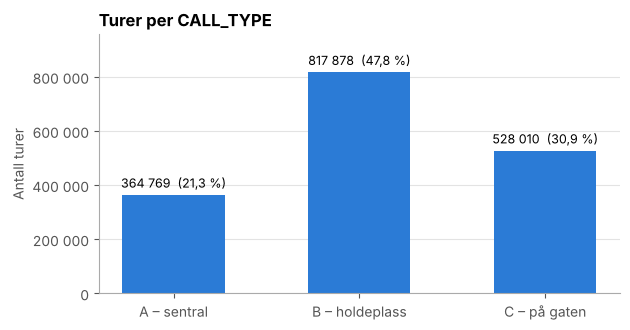

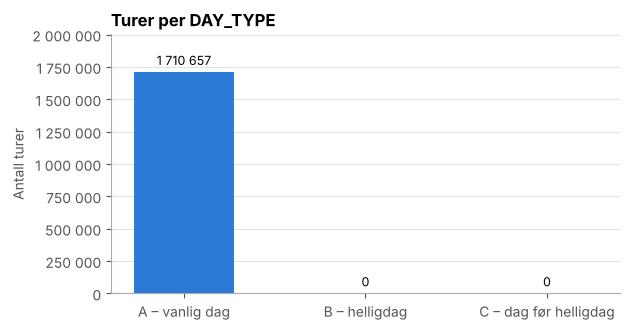

DAY_TYPE
A    1.0
Name: proportion, dtype: float64


In [24]:
# Figur 1 og 2: turer per CALL_TYPE og DAY_TYPE
def stolpediagram(antall, etiketter, tittel, filnavn, med_andel):
    fig, ax = plt.subplots()
    stolper = ax.bar([etiketter[k] for k in antall.index], antall.values, color=FARGE, width=0.55)
    for stolpe, v in zip(stolper, antall.values):
        tekst = f"{tall(v)}  ({tall(100 * v / antall.sum(), 1)} %)" if med_andel else tall(v)
        ax.annotate(tekst, (stolpe.get_x() + stolpe.get_width() / 2, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, antall.max() * 1.17)
    ax.set_ylabel("Antall turer")
    ax.set_title(tittel)
    tusenskille(ax)
    lagre(fig, filnavn)


stolpediagram(df["CALL_TYPE"].value_counts().reindex(["A", "B", "C"], fill_value=0),
              {"A": "A – sentral", "B": "B – holdeplass", "C": "C – på gaten"},
              "Turer per CALL_TYPE", "figur1_call_type.png", med_andel=True)
stolpediagram(df["DAY_TYPE"].value_counts().reindex(["A", "B", "C"], fill_value=0),
              {"A": "A – vanlig dag", "B": "B – helligdag", "C": "C – dag før helligdag"},
              "Turer per DAY_TYPE", "figur2_day_type.png", med_andel=False)

print(df["DAY_TYPE"].value_counts(normalize=True))

Plottet DAY_TYPE for å se fordelingen mellom de ulike klassene, og vi ser at den alltid er A som vil si at det ikke er noe variasjon og behov for videre analyse.

## 6.2 GPS-punkter og varighet

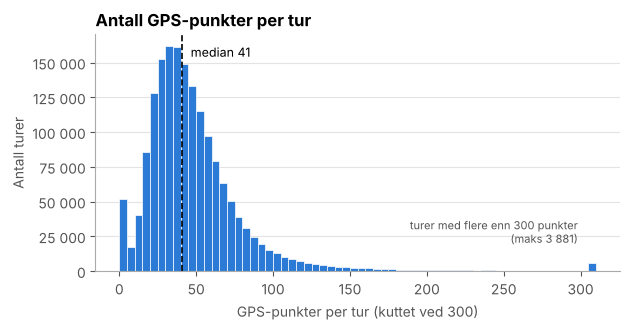

In [25]:
# Figur 3: GPS-punkter per tur. Turer med flere enn TAK punkter samles i én stolpe helt til høyre.
TAK = 300
punkter = df["N_POINTS"]
fig, ax = plt.subplots()
ax.hist(punkter.clip(upper=TAK + 5), bins=np.arange(0, TAK + 11, 5),
        color=FARGE, edgecolor="white", linewidth=0.5)
median = punkter.median()
ax.axvline(median, color="black", linestyle="--", linewidth=1.2)
ax.annotate(f"median {tall(median)}", (median, 1), xycoords=("data", "axes fraction"),
            xytext=(6, -16), textcoords="offset points", fontsize=9)
ax.text(0.92, 0.12, f"turer med flere enn {TAK} punkter\n(maks {tall(punkter.max())})",
        transform=ax.transAxes, ha="right", fontsize=8, color="#555555")
ax.set_xlabel(f"GPS-punkter per tur (kuttet ved {TAK})")
ax.set_ylabel("Antall turer")
ax.set_title("Antall GPS-punkter per tur")
tusenskille(ax)
lagre(fig, "figur3_gps_punkter.png")

In [26]:
# Nøkkeltall til teksten under. Varighet i timer, kun turer med minst 3 punkter.
display(df["N_POINTS"].describe())
(df.loc[df["N_POINTS"] >= 3, "DURATION_S"] / 3600).describe().round(2)

count    1.710657e+06
mean     4.875811e+01
std      4.565224e+01
min      0.000000e+00
25%      2.800000e+01
50%      4.100000e+01
75%      5.900000e+01
max      3.881000e+03
Name: N_POINTS, dtype: float64

count    1666757.00
mean           0.20
std            0.19
min            0.01
25%            0.12
50%            0.17
75%            0.24
max           16.17
Name: DURATION_S, dtype: float64

POLYLINE inneholder GPS punktene for hver tur, og er derfor viktig for flere av analysene senere. Vi undersøkte hvor mange GPS punkter hver tur har. En vanlig tur har rundt 41 GPS punkter i median, mens gjennomsnittet ligger på omtrent 49 punkter.  
Varigheten ble beregnet ut fra at det er 15 sekunder mellom hvert GPS punkt. For å få en mer pålitelig varighetsanalyse tok vi kun med turer med minst 3 GPS punkter. Medianen på varigheten er omtrent 0.17 timer, altså rundt 10 minutter, mens gjennomsnittet er omtrent 0.20 timer eller 12 minutter. De fleste turene er derfor relativt korte, men vi ser også noen tydelige outliers. Den lengste turen er på omtrent 16.17 timer, som skiller seg mye fra resten av datasettet. Vi velger likevel ikke å fjerne disse kun fordi de er outliers, siden vi ikke vet om de faktisk er feilregistreringer.

## 6.3 Turer per taxi

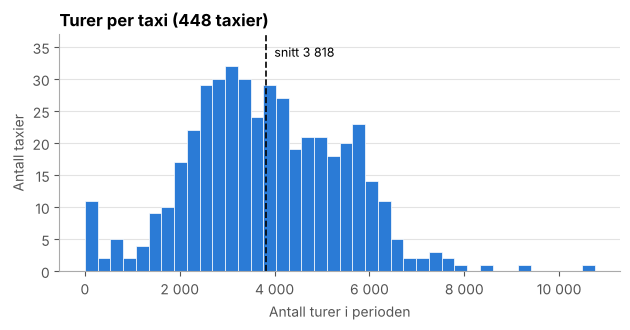

In [27]:
# Figur 4: turer per taxi
tur_per_taxi = df["TAXI_ID"].value_counts()

fig, ax = plt.subplots()
ax.hist(tur_per_taxi, bins=40, color=FARGE, edgecolor="white", linewidth=0.5)
ax.set_ylim(top=ax.get_ylim()[1] * 1.1)  # plass til teksten over stolpene
snitt = tur_per_taxi.mean()
ax.axvline(snitt, color="black", linestyle="--", linewidth=1.2)
ax.annotate(f"snitt {tall(snitt)}", (snitt, 1), xycoords=("data", "axes fraction"),
            xytext=(6, -16), textcoords="offset points", fontsize=9)
ax.set_xlabel("Antall turer i perioden")
ax.set_ylabel("Antall taxier")
ax.set_title(f"Turer per taxi ({len(tur_per_taxi)} taxier)")
tusenskille(ax, "x")
lagre(fig, "figur4_turer_per_taxi.png")

Fordelingen av antall turer per taxi viser at de fleste taxiene har mellom omtrent 2000 og 6000 turer. Det finnes også noen taxier med veldig få turer, og noen få med betydelig flere turer enn resten. Den høyeste ligger på over 10 000 turer, som skiller seg tydelig ut fra hoveddelen av datasettet.

---
# 7. Ugyldige turer og outliers (kort)

Skill mellom **feil i data**, **ugyldige turer etter oppgavens definisjon** (< 3 punkter, Part 2 oppg. 7) og **sjeldne, men gyldige** turer.
- Tell turer med 0, 1 og 2 punkter.
- Se på ekstreme verdier i `DURATION_S`, `distance_km` og `avg_speed_kmh` (`describe()`, høyeste verdier). Er de fysisk mulige?

In [28]:
# Turer med færre enn 3 punkter (ugyldige etter oppgavens definisjon)
ugyldige = df["N_POINTS"].value_counts().reindex([0, 1, 2], fill_value=0)
print(ugyldige)
print(f"Totalt {ugyldige.sum():,} ugyldige turer ({100 * ugyldige.sum() / len(df):.2f} %)")

N_POINTS
0     5900
1    30606
2     7394
Name: count, dtype: int64
Totalt 43,900 ugyldige turer (2.57 %)


Her ser vi at det er en del turer som har under 3 gps-punkter. Ut ifra definisjonen så skal disse tolkes som ugyldige turer. Det enkleste ville vært å fjerne disse fra datasettet, men siden et av spørsmålene vi skal svare på i task 2 handler om å finne ut hvor mange turer som har mindre enn 3 punkter, har vi valgt å beholde dem enn så lenge.

In [29]:
gyldige = df[df["N_POINTS"] >= 3]
display(gyldige[["DURATION_S", "distance_km", "avg_speed_kmh"]].describe())

print(f"Gyldige turer lenger enn 3 timer: {(gyldige.DURATION_S > 3 * 3600).sum():,}")
print(f"Gyldige turer med snittfart over 120 km/t: {(gyldige.avg_speed_kmh > 120).sum():,}")
print(f"Turer med minst ett GPS-hopp (> {MAX_STEP_KM} km på 15 s): {(df.gps_jumps > 0).sum():,}")

# De mest ekstreme turene, for å vurdere om de er fysisk mulige
gyldige.nlargest(5, "avg_speed_kmh")[["TRIP_ID", "N_POINTS", "DURATION_S", "distance_km", "avg_speed_kmh", "gps_jumps"]]

,DURATION_S,distance_km,avg_speed_kmh
count,1.666757e+06,1.666757e+06,1.666757e+06
mean,7.352265e+02,5.588149e+00,2.703287e+01
std,6.836848e+02,7.196725e+00,1.346019e+01
min,3.000000e+01,0.000000e+00,0.000000e+00
25%,4.200000e+02,2.467236e+00,1.805191e+01
50%,6.150000e+02,4.006285e+00,2.391239e+01
75%,8.700000e+02,6.609360e+00,3.271191e+01
max,5.820000e+04,7.515933e+02,2.078393e+02


Gyldige turer lenger enn 3 timer: 847
Gyldige turer med snittfart over 120 km/t: 201
Turer med minst ett GPS-hopp (> 1.0 km på 15 s): 21,226


,TRIP_ID,N_POINTS,DURATION_S,distance_km,avg_speed_kmh,gps_jumps
1380949,1398627070620000089,3,30,1.731994,207.839284,0
197811,1376395825620000484,3,30,1.669384,200.326065,0
142827,1375266328620000038,3,30,1.626494,195.179322,0
495994,1381909330620000367,3,30,1.564293,187.715179,0
1704364,1404052658620000307,3,30,1.557050,186.846020,0


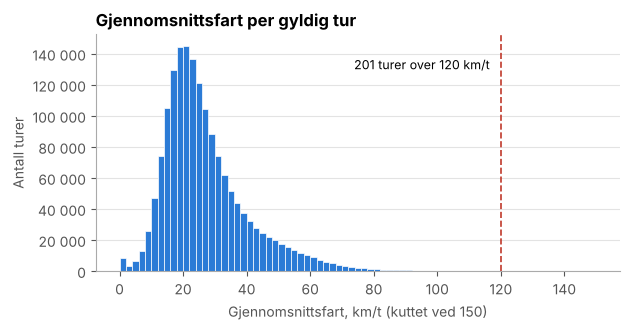

In [30]:
# Figur 5: gjennomsnittsfart for gyldige turer (GPS-hopp er holdt utenfor distansen)
TAK = 150
fart = gyldige["avg_speed_kmh"]
fig, ax = plt.subplots()
ax.hist(fart.clip(upper=TAK), bins=75, range=(0, TAK), color=FARGE, edgecolor="white", linewidth=0.5)
ax.axvline(120, color="#c0392b", linestyle="--", linewidth=1.2)
ax.annotate(f"{tall((fart > 120).sum())} turer over 120 km/t", (120, 1),
            xycoords=("data", "axes fraction"), xytext=(-8, -25), textcoords="offset points",
            ha="right", fontsize=9)
ax.set_xlabel(f"Gjennomsnittsfart, km/t (kuttet ved {TAK})")
ax.set_ylabel("Antall turer")
ax.set_title("Gjennomsnittsfart per gyldig tur")
tusenskille(ax)
lagre(fig, "figur5_snittfart.png")

Vi ser det at for både duration, distance_km og avg_speed_kmh så finnes det noen ekstreme max verdier. Disse verdiene er såpass høye at de ikke lar seg forklares realistisk. Disse feilene må skyldes feil og bør derfor ikke være med, da de kan forrurense datainnsikt.

## 7.1 Beslutning per type

*Tallene gjelder de 1 710 657 turene etter rensing, og er hentet fra cellene over. Tiltakene er det `insert_data.py` gjør. Begrunnelsene må dere skrive selv.*

| Type | Regel / terskel | Antall (andel) | Tiltak | Begrunnelse |
|---|---|---|---|---|
| < 3 punkter | `N_POINTS < 3` | 43 900 (2,57 %) | Beholdes i databasen | Vi har valgt å behold dem for å kunne svare på spørsmål i task 2 |
| GPS-hopp | Steg > 1 km på 15 s (> 240 km/t) | 21 226 turer | Punktene lagres, men steget holdes utenfor `distance_km` | |
| Ekstrem varighet / hastighet | > 3 timer / > 120 km/t snittfart | 847 / 201 gyldige turer | Beholdes | |
| `MISSING_DATA = True` | `MISSING_DATA == True` | 10 (i rådata) | Fjernes | |
| Duplikat `TRIP_ID` | Samme `TRIP_ID` flere ganger | 80 ID-er, 81 overskytende rader (i rådata) | Fjern de 3 helt identiske radene, behold resten | |

Husk: Part 2 oppg. 7 spør om antall turer med < 3 punkter. Fjerner dere dem, hvordan svarer dere da på oppgaven?